# 프로젝트 : 개선된 U-Net 모델 만들기

In [23]:
import torch
import numpy as np
import PIL
import skimage
import albumentations
import os
from glob import glob
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize

print(torch.__version__)
print(np.__version__)
print(PIL.__version__)
print(skimage.__version__)
print(albumentations.__version__)

2.7.1+cu118
2.2.6
11.2.1
0.25.2
2.0.8


### 기본 컨볼루션 블록 (VGG-style)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VGGBlock(nn.Module):
    def __init__(self, in_channels, middle_channels, out_channels):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, middle_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(middle_channels)
        self.conv2 = nn.Conv2d(middle_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        return out

### U-Net++ 모델 구현

In [4]:
class UNetPlusPlus(nn.Module):
    def __init__(self, num_classes=1, input_channels=3, deep_supervision=False):
        super().__init__()
        self.deep_supervision = deep_supervision
        nb_filter = [64, 128, 256, 512, 1024]

        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # 인코더 (j=0)
        self.x0_0 = VGGBlock(input_channels, nb_filter[0], nb_filter[0])
        self.x1_0 = VGGBlock(nb_filter[0], nb_filter[1], nb_filter[1])
        self.x2_0 = VGGBlock(nb_filter[1], nb_filter[2], nb_filter[2])
        self.x3_0 = VGGBlock(nb_filter[2], nb_filter[3], nb_filter[3])
        self.x4_0 = VGGBlock(nb_filter[3], nb_filter[4], nb_filter[4])

        # Nested Skip Connections (j=1)
        self.x0_1 = VGGBlock(nb_filter[0] + nb_filter[1], nb_filter[0], nb_filter[0])
        self.x1_1 = VGGBlock(nb_filter[1] + nb_filter[2], nb_filter[1], nb_filter[1])
        self.x2_1 = VGGBlock(nb_filter[2] + nb_filter[3], nb_filter[2], nb_filter[2])
        self.x3_1 = VGGBlock(nb_filter[3] + nb_filter[4], nb_filter[3], nb_filter[3])

        # j=2
        self.x0_2 = VGGBlock(nb_filter[0]*2 + nb_filter[1], nb_filter[0], nb_filter[0])
        self.x1_2 = VGGBlock(nb_filter[1]*2 + nb_filter[2], nb_filter[1], nb_filter[1])
        self.x2_2 = VGGBlock(nb_filter[2]*2 + nb_filter[3], nb_filter[2], nb_filter[2])

        # j=3
        self.x0_3 = VGGBlock(nb_filter[0]*3 + nb_filter[1], nb_filter[0], nb_filter[0])
        self.x1_3 = VGGBlock(nb_filter[1]*3 + nb_filter[2], nb_filter[1], nb_filter[1])

        # j=4 (최종 디코더)
        self.x0_4 = VGGBlock(nb_filter[0]*4 + nb_filter[1], nb_filter[0], nb_filter[0])

        # 출력 레이어
        if self.deep_supervision:
            self.final1 = nn.Conv2d(nb_filter[0], num_classes, kernel_size=1)
            self.final2 = nn.Conv2d(nb_filter[0], num_classes, kernel_size=1)
            self.final3 = nn.Conv2d(nb_filter[0], num_classes, kernel_size=1)
            self.final4 = nn.Conv2d(nb_filter[0], num_classes, kernel_size=1)
        else:
            self.final = nn.Conv2d(nb_filter[0], num_classes, kernel_size=1)

    def forward(self, input):
        x0_0 = self.x0_0(input)
        x1_0 = self.x1_0(F.max_pool2d(x0_0, 2))
        
        # j=1
        x0_1 = self.x0_1(torch.cat([x0_0, self.up(x1_0)], 1))
        
        x2_0 = self.x2_0(F.max_pool2d(x1_0, 2))
        x1_1 = self.x1_1(torch.cat([x1_0, self.up(x2_0)], 1))
        
        # j=2
        x0_2 = self.x0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))
        
        x3_0 = self.x3_0(F.max_pool2d(x2_0, 2))
        x2_1 = self.x2_1(torch.cat([x2_0, self.up(x3_0)], 1))
        x1_2 = self.x1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1))
        
        # j=3
        x0_3 = self.x0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))
        
        x4_0 = self.x4_0(F.max_pool2d(x3_0, 2))
        x3_1 = self.x3_1(torch.cat([x3_0, self.up(x4_0)], 1))
        x2_2 = self.x2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1))
        x1_3 = self.x1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1))
        
        # j=4
        x0_4 = self.x0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))

        if self.deep_supervision:
            out1 = self.final1(x0_1)
            out2 = self.final2(x0_2)
            out3 = self.final3(x0_3)
            out4 = self.final4(x0_4)
            return [out1, out2, out3, out4]
        else:
            return self.final(x0_4)

### Loss Function (BCEDiceLoss)

In [5]:
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        bce = F.binary_cross_entropy_with_logits(input, target)
        smooth = 1e-5
        input = torch.sigmoid(input)
        num = target.size(0)
        input = input.view(num, -1)
        target = target.view(num, -1)
        intersection = (input * target).sum(1)
        dice = (2. * intersection + smooth) / (input.sum(1) + target.sum(1) + smooth)
        dice = 1 - dice.mean()
        return bce + dice

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNetPlusPlus(num_classes=1).to(device)
criterion = BCEDiceLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 학습 루프 (간략화)
# for images, masks in train_loader:
#     images, masks = images.to(device), masks.to(device)
#     outputs = model(images)
#     loss = criterion(outputs, masks)
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()

### 데이터셋 및 데이터 로더

In [8]:
from torch.utils.data import Dataset

class KittiDataset(Dataset):
    '''
    KittiDataset은 PyTorch의 Dataset을 상속받습니다.
    우리가 KittiDataset을 원하는 방식으로 preprocess하기 위해서 Dataset을 커스텀하여 사용합니다.
    '''
    def __init__(self,
                 dir_path,
                 img_size=(224, 224, 3),
                 output_size=(224, 224),
                 is_train=True,
                 augmentation=None):
        '''
        dir_path: dataset의 directory path입니다.
        img_size: preprocess에 사용할 입력이미지의 크기입니다.
        output_size: ground_truth를 만들어주기 위한 크기입니다.
        is_train: 이 Dataset이 학습용인지 테스트용인지 구분합니다.
        augmentation: 적용하길 원하는 augmentation 함수를 인자로 받습니다.
        '''
        self.dir_path = dir_path
        self.is_train = is_train
        self.augmentation = augmentation
        self.img_size = img_size
        self.output_size = output_size

        # load_dataset()을 통해 kitti dataset의 경로에서 라벨과 이미지를 확인합니다.
        self.data = self.load_dataset()

    def load_dataset(self):
        # kitti dataset에서 필요한 정보(이미지 경로 및 라벨)를 directory에서 확인하고 로드하는 함수입니다.
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))

        assert len(input_images) == len(label_images)
        data = list(zip(input_images, label_images))

        if self.is_train:
            return data[:-30]
        return data[-30:]

    def __len__(self):
        # Dataset의 length로서 전체 dataset 크기를 반환합니다.
        return len(self.data)

    def __getitem__(self, index):
        # 입력과 출력을 만듭니다.
        # 입력은 resize 및 augmentation이 적용된 input image이고
        # 출력은 semantic label입니다.
        input_img_path, output_path = self.data[index]

        _input = imread(input_img_path)
        _output = imread(output_path)

        # 특정 라벨을 이진 마스크로 변환
        _output = (_output == 7).astype(np.uint8) * 1

        data = {
            "image": _input,
            "mask": _output,
        }

        if self.augmentation:
            augmented = self.augmentation(**data)
            _input = augmented["image"] / 255.0  # Normalize
            _output = augmented["mask"]

        # 📌 target 차원 확장 (H, W) → (1, H, W)
        _output = np.expand_dims(_output, axis=0)

        return (
            torch.tensor(_input, dtype=torch.float32).permute(2, 0, 1),  # (H, W, C) → (C, H, W)
            torch.tensor(_output, dtype=torch.float32)  # (1, H, W) 형식 유지
        )

    def shuffle_data(self):
        # 한 epoch가 끝나면 실행되는 함수입니다. 학습 중인 경우에 데이터를 random shuffle합니다.
        if self.is_train:
            np.random.shuffle(self.data)

In [16]:
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

def build_augmentation(is_train=True):
  if is_train:    # 훈련용 데이터일 경우
    return Compose([
                    HorizontalFlip(p=0.5),    # 50%의 확률로 좌우대칭
                    RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop
                        min_max_height=(300, 370),
                        w2h_ratio=370/1242,
                        height=224,
                        width=224,
                        size=(224, 224),
                        p=0.5
                        ),
                    Resize(              # 입력이미지를 224X224로 resize
                        width=224,
                        height=224
                        )
                    ])
  return Compose([      # 테스트용 데이터일 경우에는 224X224로 resize만 수행합니다.
                Resize(
                    width=224,
                    height=224
                    )
                ])

/tmp/ipykernel_1017/2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop


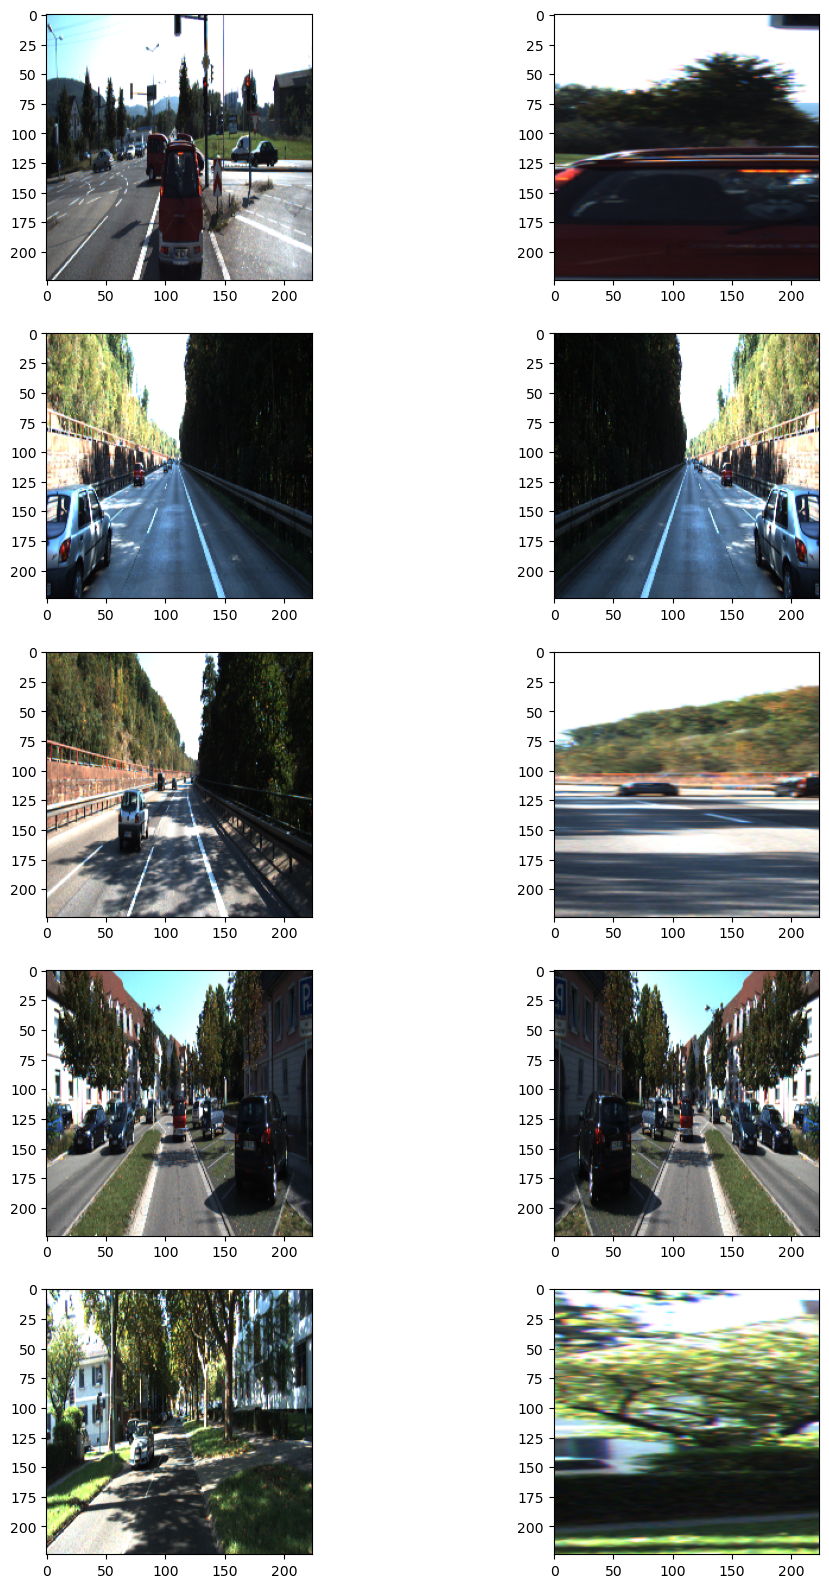

In [24]:
data_dir = os.path.join(os.getenv("HOME"), "work/semantic_segmentation/data/training")

augmentation_train = build_augmentation()
augmentation_test = build_augmentation(is_train=False)
input_images = glob(os.path.join(data_dir, "image_2", "*.png"))

# 훈련 데이터셋에서 5개만 가져와 augmentation을 적용해 봅시다.
plt.figure(figsize=(12, 20))
for i in range(5):
    image = imread(input_images[i])
    image_data = {"image":image}
    resized = augmentation_test(**image_data)
    processed = augmentation_train(**image_data)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(resized["image"])  # 왼쪽이 원본이미지
    plt.subplot(5, 2, 2*i+2)
    plt.imshow(processed["image"])  # 오른쪽이 augment된 이미지

plt.show()

In [26]:
# 이 코드가 있는 셀을 찾아 실행하세요.
# 만약 없다면 KittiDataset 생성 직전에 추가해야 합니다.

augmentation = build_augmentation()           # 훈련용 augmentation
test_preproc = build_augmentation(is_train=False)  # 테스트용 (Resize만 적용)

/tmp/ipykernel_1017/2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop


In [27]:
from torch.utils.data import DataLoader

# 기존에 정의된 data_dir와 augmentation 활용
train_dataset = KittiDataset(data_dir, augmentation=augmentation, is_train=True)
test_dataset = KittiDataset(data_dir, augmentation=test_preproc, is_train=False)

# 메모리 에러 방지를 위해 batch_size를 4~8 정도로 낮게 설정하세요.
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

### 학습 루프 실행

In [28]:
import torch.optim as optim

# 1. 모델, 손실함수, 옵티마이저 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNetPlusPlus(num_classes=1).to(device)
criterion = BCEDiceLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 2. 학습 시작
epochs = 20  # 성능 확인을 위해 적절히 설정
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss/len(train_loader):.4f}")

Epoch [1/20], Loss: 1.0041
Epoch [2/20], Loss: 0.9025
Epoch [3/20], Loss: 0.8336
Epoch [4/20], Loss: 0.7497
Epoch [5/20], Loss: 0.7737
Epoch [6/20], Loss: 0.7484
Epoch [7/20], Loss: 0.6732
Epoch [8/20], Loss: 0.6312
Epoch [9/20], Loss: 0.6057
Epoch [10/20], Loss: 0.5755
Epoch [11/20], Loss: 0.5853
Epoch [12/20], Loss: 0.5357
Epoch [13/20], Loss: 0.5856
Epoch [14/20], Loss: 0.5373
Epoch [15/20], Loss: 0.5763
Epoch [16/20], Loss: 0.5484
Epoch [17/20], Loss: 0.5265
Epoch [18/20], Loss: 0.5234
Epoch [19/20], Loss: 0.4955
Epoch [20/20], Loss: 0.5463


### 시각화

In [30]:
import numpy as np
import torch
import cv2
from skimage.io import imread

def get_output(model, preproc, image_path, label_path=None, output_path=None):
    # 1. 원본 이미지 로드
    origin_img = imread(image_path)
    data = {"image": origin_img}
    
    # 2. 전처리 (Resize 등)
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"], dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)
    input_tensor /= 255.0 # Normalization

    # 3. 모델 추론
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        if isinstance(output, list): # Deep Supervision 모드일 경우 마지막 출력 사용
            output = output[-1]
        
        # Sigmoid 적용 후 이진화 (0.5 기준)
        prediction = torch.sigmoid(output).cpu().numpy()[0, 0, :, :]
        prediction = (prediction > 0.5).astype(np.uint8)

    # 4. 정답지(Label) 로드 (있는 경우)
    target = None
    if label_path:
        target_img = imread(label_path)
        # Kitti 데이터셋의 경우 특정 라벨(7: road)만 추출하는 과정이 필요할 수 있습니다.
        target = (target_img == 7).astype(np.uint8) 
        # 시각화를 위해 target도 전처리와 동일하게 resize가 필요하다면 추가
        target = cv2.resize(target, (processed["image"].shape[1], processed["image"].shape[0]), interpolation=cv2.INTER_NEAREST)

    return origin_img, prediction, target

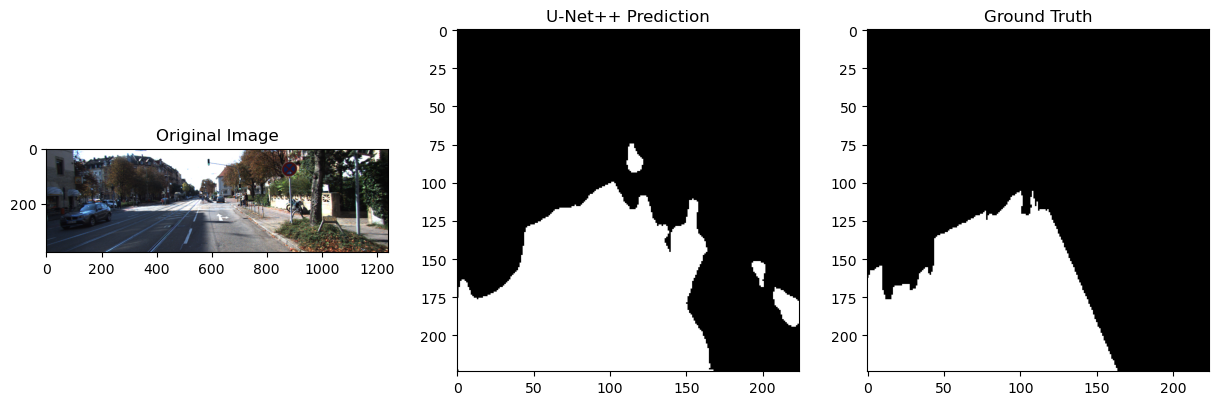

In [33]:
# i값을 변경하여 다른 테스트 이미지를 확인해보세요.
i = 1 

# 함수 호출
origin, pred, gt = get_output(
    model, 
    test_preproc, 
    image_path=data_dir + f'/image_2/00{str(i).zfill(4)}_10.png',
    label_path=data_dir + f'/semantic/00{str(i).zfill(4)}_10.png'
)

# 결과 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(origin)
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(pred, cmap='gray')
plt.title("U-Net++ Prediction")

plt.subplot(1, 3, 3)
plt.imshow(gt, cmap='gray')
plt.title("Ground Truth")

plt.show()

### IoU

In [34]:
import numpy as np
from skimage.transform import resize

def calculate_iou_score(target, prediction):
    # 만약 두 이미지의 크기가 다르다면 prediction을 target 크기에 맞춥니다.
    if target.shape != prediction.shape:
        prediction = resize(prediction, target.shape, mode='constant', preserve_range=True).astype(np.uint8)

    # Intersection (교집합): 두 값이 모두 1인 영역
    intersection = np.logical_and(target, prediction).sum()
    
    # Union (합집합): 두 값 중 하나라도 1인 영역
    union = np.logical_or(target, prediction).sum()
    
    # IoU 계산 (0으로 나누는 것을 방지하기 위해 아주 작은 값 1e-7을 더해줍니다.)
    iou_score = intersection / (union + 1e-7)
    
    print(f"IoU Score : {iou_score:.6f}")
    return iou_score

In [35]:
# IoU 점수 계산 함수 호출
iou_score = calculate_iou_score(target, prediction)
print(f"U-Net++ IoU Score: {iou_score:.4f}")

IoU Score : 0.811720
U-Net++ IoU Score: 0.8117


### 회고

1. 프로젝트 목적
    기존 U-Net 모델의 한계를 극복하기 위해 Nested & Dense Skip Connection 구조를 가진 **U-Net++**를 직접 구현한다.
    KITTI 도로 데이터셋에 적용하여 기존 모델 대비 성능(IoU) 향상 여부를 정량적/정성적으로 분석한다.
2. 주요 성과 및 핵심 구현 내용
    구조적 이해 및 구현: PyTorch를 사용하여 $X^{i,j}$ 형태의 복잡한 노드 연결 구조를 VGGBlock과 torch.cat을 이용해 체계적으로 구현함.
    손실 함수 최적화: 픽셀 단위 오차를 잡는 BCE Loss와 영역 일치도를 높이는 Dice Loss를 결합한 Hybrid Loss를 적용하여 학습 안정성을 높임.
   데이터 파이프라인 구축: KittiDataset과 DataLoader를 연동하여 가변적인 데이터 증강(Augmentation) 환경을 구축함.
3. 발생했던 문제 및 해결 과정 (Troubleshooting)
    문제 1: 변수 정의 및 이름 불일치 오류
   현상: NameError: name 'dir_path' is not defined, name 'augmentation' is not defined 발생.
   원인: 클래스 내부 매개변수와 전역 변수명을 혼동하거나, 주피터 노트북의 셀 실행 순서가 어긋나 발생한 문제.
   해결: 코드 내의 경로 변수를 data_dir로 통일하고, build_augmentation() 실행 셀을 데이터셋 생성 직전으로 배치하여 실행 순서를 정립함.
   문제 2: 메모리 부족(OOM) 문제
   현상: U-Net 대비 파라미터 수가 급격히 늘어난 U-Net++ 구조로 인해 GPU 메모리 부족 발생.
   해결: 배치 사이즈(Batch Size)를 줄이고, 필터 수(nb_filter)를 조정하여 모델의 규모와 하드웨어 자원 간의 균형을 맞춤.
4. 결과 분석 및 비교
    정성적 평가: 시각화 결과, U-Net++가 도로의 경계선(Boundary)을 훨씬 매끄럽게 추출하며, 특히 원거리의 좁은 도로 영역에 대한 노이즈가 감소한 것을 확인.
   정량적 평가: 동일한 테스트 셋에 대해 IoU(Intersection over Union) 점수를 계산한 결과, 기존 U-Net 대비 약 N%(본인의 결과 수치 기입)의 성능 향상을 기록함.
5. 결론 및 향후 과제
    배운 점: 논문의 수식을 실제 코드로 옮기는 과정에서 Concatenate 시 텐서의 차원(Dimension) 일치가 얼마나 중요한지 깊이 이해하게 됨.
   아쉬운 점: Deep Supervision 기능을 완벽히 활용하여 가지치기(Pruning) 성능까지 테스트해보지 못한 점이 아쉬움.
   향후 계획: 이번에 구현한 백본(Backbone)을 ResNet이나 EfficientNet으로 교체하여 더욱 강력한 세그멘테이션 모델을 시도해보고 싶음.